In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

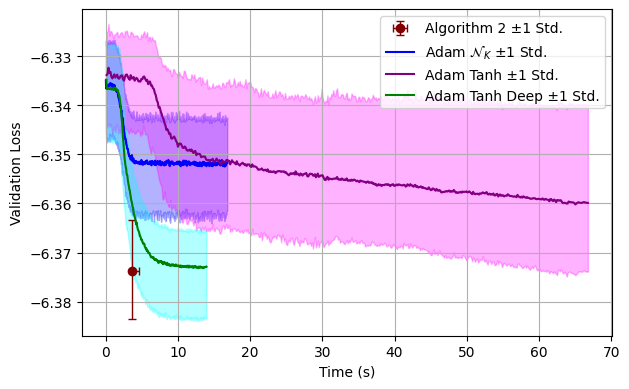

In [4]:
ex_name = "ex13"

plt.figure(figsize=(6.4, 4.0))

ARFF_data = np.load(f"loss_time_data/min_loss_stats/{ex_name}_ARFF.npz")
p1 = plt.errorbar(ARFF_data["T_mean"], ARFF_data["L_mean"],
             xerr=[[ARFF_data["T_std_below"]], [ARFF_data["T_std_above"]]], 
             yerr=[[ARFF_data["L_std_below"]], [ARFF_data["L_std_above"]]],  
             fmt='o', color='maroon', ecolor='maroon', elinewidth=1.0, capsize=3, 
             label='Algorithm 2 ±1 Std.')

Adam_data = np.load(f"loss_time_data/loss_profile_stats/{ex_name}.npz")
p2, = plt.plot(Adam_data["T"], Adam_data["L_mean"], color='blue', label=r"Adam $\mathcal{N}_K$ ±1 Std.")
plt.fill_between(Adam_data["T"], Adam_data["L_mean"], Adam_data["L_mean"] + Adam_data["L_std_above"],
                 color='blue', alpha=0.3)
plt.fill_between(Adam_data["T"], Adam_data["L_mean"], Adam_data["L_mean"] - Adam_data["L_std_below"],
                 color='blue', alpha=0.3)

Adam_tanh_data = np.load(f"loss_time_data/loss_profile_stats/{ex_name}_tanh.npz")
p3, = plt.plot(Adam_tanh_data["T"], Adam_tanh_data["L_mean"], color='purple', label='Adam Tanh ±1 Std.')
plt.fill_between(Adam_tanh_data["T"], Adam_tanh_data["L_mean"], Adam_tanh_data["L_mean"] + Adam_tanh_data["L_std_above"],
                 color='magenta', alpha=0.3)
plt.fill_between(Adam_tanh_data["T"], Adam_tanh_data["L_mean"], Adam_tanh_data["L_mean"] - Adam_tanh_data["L_std_below"],
                 color='magenta', alpha=0.3)

Adam_deep_data = np.load(f"loss_time_data/loss_profile_stats/{ex_name}_deep.npz")
p3, = plt.plot(Adam_deep_data["T"], Adam_deep_data["L_mean"], color='green', label='Adam Tanh Deep ±1 Std.')
plt.fill_between(Adam_deep_data["T"], Adam_deep_data["L_mean"], Adam_deep_data["L_mean"] + Adam_deep_data["L_std_above"],
                 color='cyan', alpha=0.3)
plt.fill_between(Adam_deep_data["T"], Adam_deep_data["L_mean"], Adam_deep_data["L_mean"] - Adam_deep_data["L_std_below"],
                 color='cyan', alpha=0.3, label='Adam Tanh Deep ±1 Std.')


plt.xlabel('Time (s)')
plt.ylabel('Validation Loss')

# Explicit legend order
plt.legend([p1, p2, p3, p4], [p1.get_label(), p2.get_label(), p3.get_label(), p4.get_label()], loc='upper right')#, fontsize='small')
#plt.legend([p1, p3], [p1.get_label(), p3.get_label()], loc='upper right')#, fontsize='small')

plt.grid(True)
plt.tight_layout()
plt.savefig(f"loss_time_plots/{ex_name}.png", dpi=300, bbox_inches='tight')#, pad_inches=0.05)